In [359]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from numpy._core.defchararray import upper
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import f_classif, SelectKBest
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
import warnings
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## **Paso 1: Busca un conjunto de datos**

**Description**

This dataset simulates a realistic academic environment for 10,000 students and is designed for predicting student dropout. It includes demographic, behavioral, and academic performance features such as GPA, semester GPA, CGPA, study habits, attendance, stress index, parental education, and department.

Although synthetic, the data closely mimics real-world student distributions, including slight skewness in income and stress, missing values (~5%) in some features, and logical correlations between academic performance and dropout risk.

**Target variable:**

Dropout (0 = retained, 1 = dropped out)


**Key Features:**

-Student_ID: Unique student identifier

-Age: Student age in years

-Gender: Male / Female

-Family_Income: Monthly family income

-Internet_Access: Yes / No

-Study_Hours_per_Day: Average study hours per day

-Attendance_Rate: Percentage of attendance

-Assignment_Delay_Days: Average assignment delay in days

-Travel_Time_Minutes: Daily commute in minutes

-Part_Time_Job: Yes / No

-Scholarship: Yes / No

-Stress_Index: Self-reported stress level (1–10)

-GPA, Semester_GPA, CGPA: Academic performance

-Semester: Current year (Year 1–4)

-Department: Science, Arts, Business, CS, Engineering

-Parental_Education: Highest education of parents

**Dataset Characteristics:**

-Rows: 10,000

-Columns: 19

-Dropout rate: 23.5%

Contains both categorical and numerical features
Missing values are present in 5–5.1% of some columns (realistic for educational datasets)


In [360]:
total_data = pd.read_csv("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/raw/student_dropout_dataset_v3.csv")
total_data


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


## **Paso 2: Desarrolla un modelo**
Una vez hayas encontrado tu conjunto de datos ideal, analízalo y entrena un modelo. Optimízalo si fuera necesario.

In [361]:
#Conocer las dimensiones

total_data.shape
print(f"Hay {total_data.shape[0]} filas y {total_data.shape[1]} columnas")

Hay 10000 filas y 19 columnas


In [362]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

In [363]:
total_data.dropna(inplace=True)

In [364]:
total_data.drop(columns=["Student_ID"], inplace=True)

# Elimino 2 de las métricas  relacionadas a las notas.
total_data.drop(columns=["Semester_GPA","CGPA"], inplace=True)

In [365]:
vars_numericas = total_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
vars_categoricas = total_data.select_dtypes(include=["object"]).columns.tolist()
print(vars_categoricas,vars_numericas)

['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education'] ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Dropout']


In [366]:
num_duplicates = total_data.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicates}")

if num_duplicates > 0:
    total_data = total_data.drop_duplicates().reset_index(drop = True)
    print(f"Número duplicados borrados. Ahora hay {total_data.shape[0]} datos")
else:
    print("No se han encontrado duplicados")

Número de filas duplicadas: 0
No se han encontrado duplicados


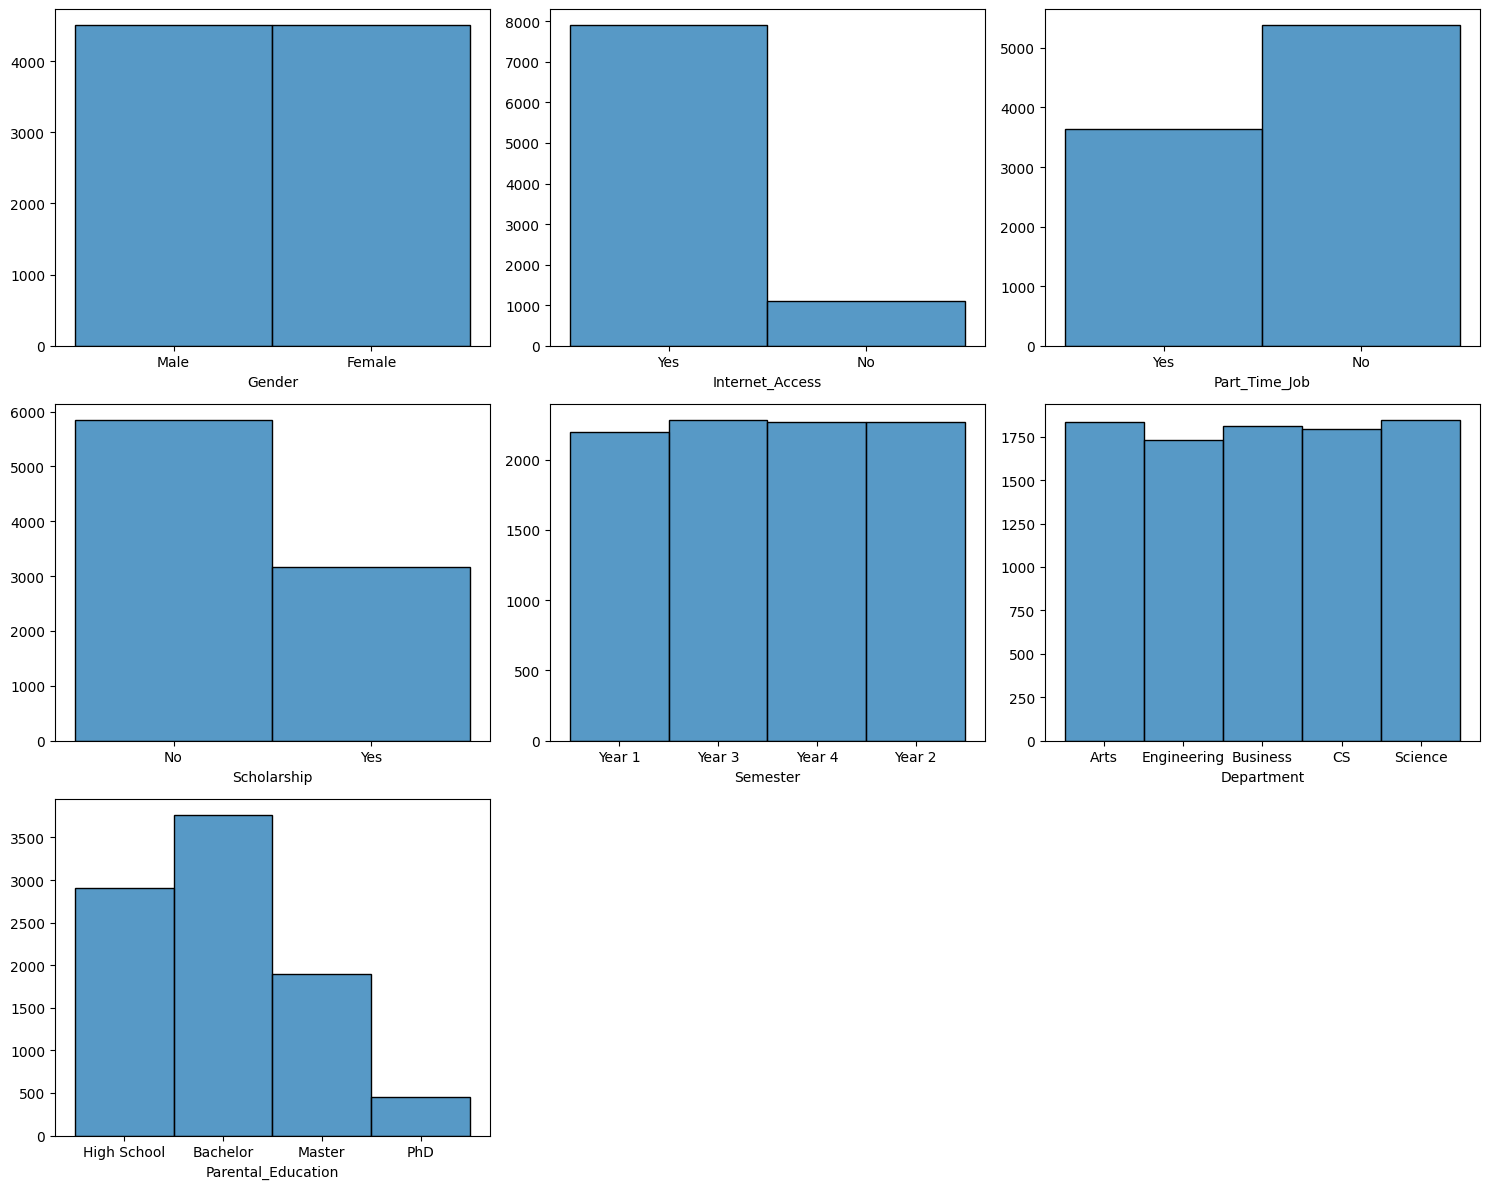

In [367]:
n_cols = 3
n_rows = math.ceil(len(vars_categoricas) / n_cols)
fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axis = axis.flatten()   

for i, col in enumerate(vars_categoricas):
    sns.histplot(ax=axis[i], data=total_data, x=col).set_ylabel(None)

for j in range(len(vars_categoricas), len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

Las variables numéricas son ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Dropout']


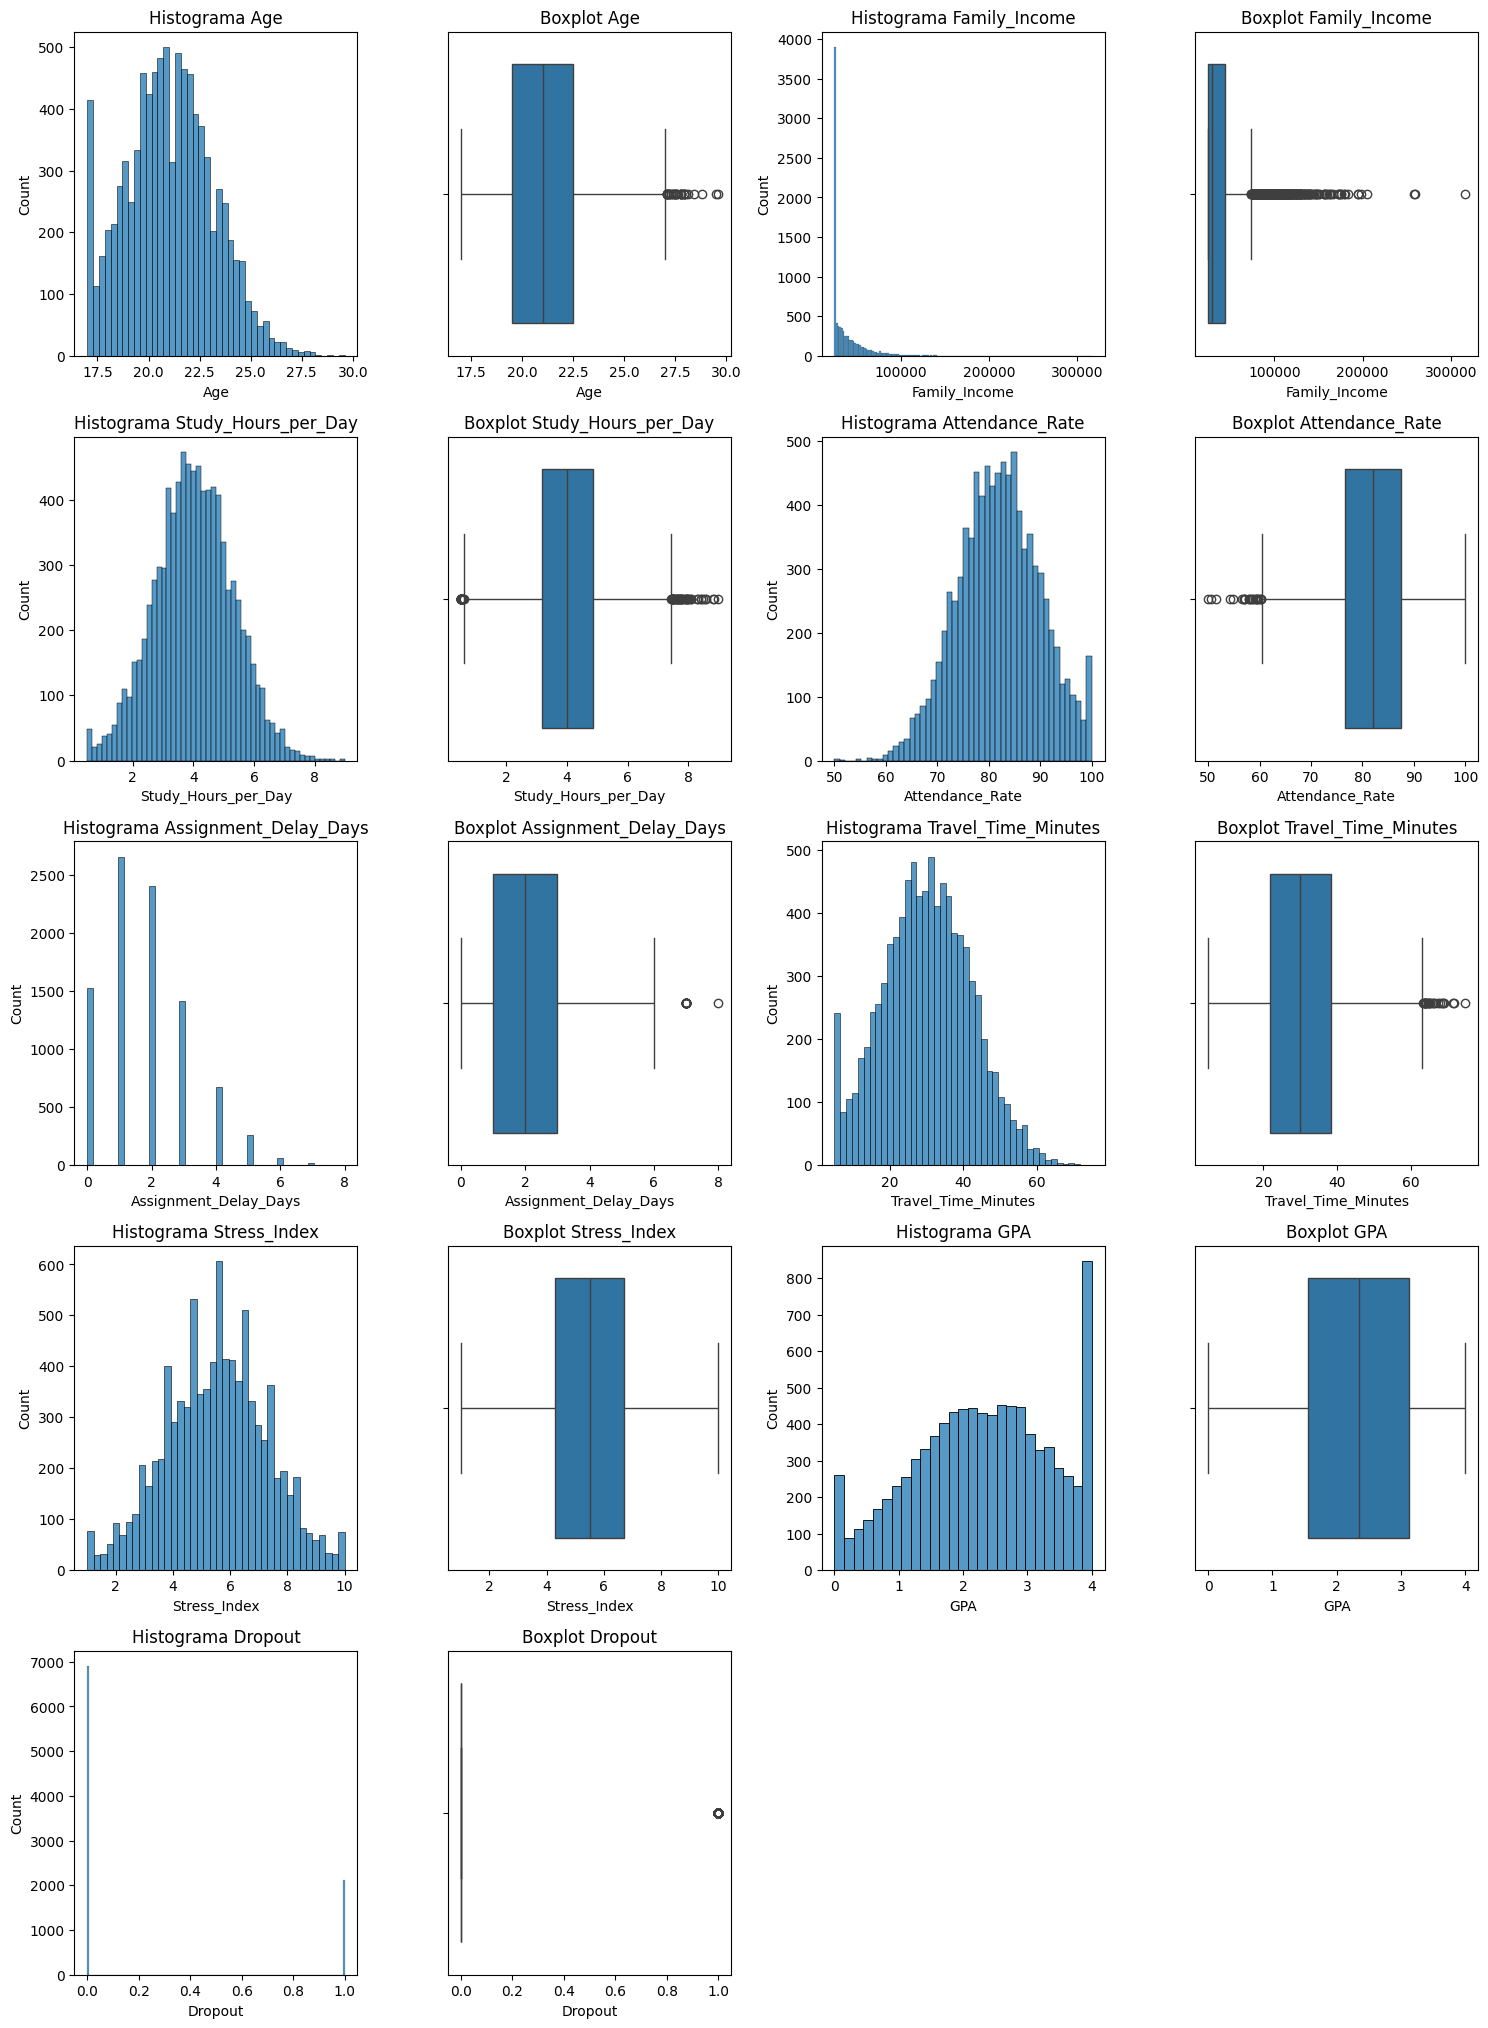

In [368]:
print(f"Las variables numéricas son {vars_numericas}")

n_cols = 4
n_rows = 2*(math.ceil(len(vars_numericas) / n_cols))

fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axis = axis.flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(data=total_data, x=col, ax=axis[2*i])
    axis[2*i].set_title(f"Histograma {col}")

    sns.boxplot(data=total_data, x=col, ax=axis[2*i + 1])
    axis[2*i + 1].set_title(f"Boxplot {col}")

# Eliminar subplots sobrantes
for j in range(2*i + 2, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

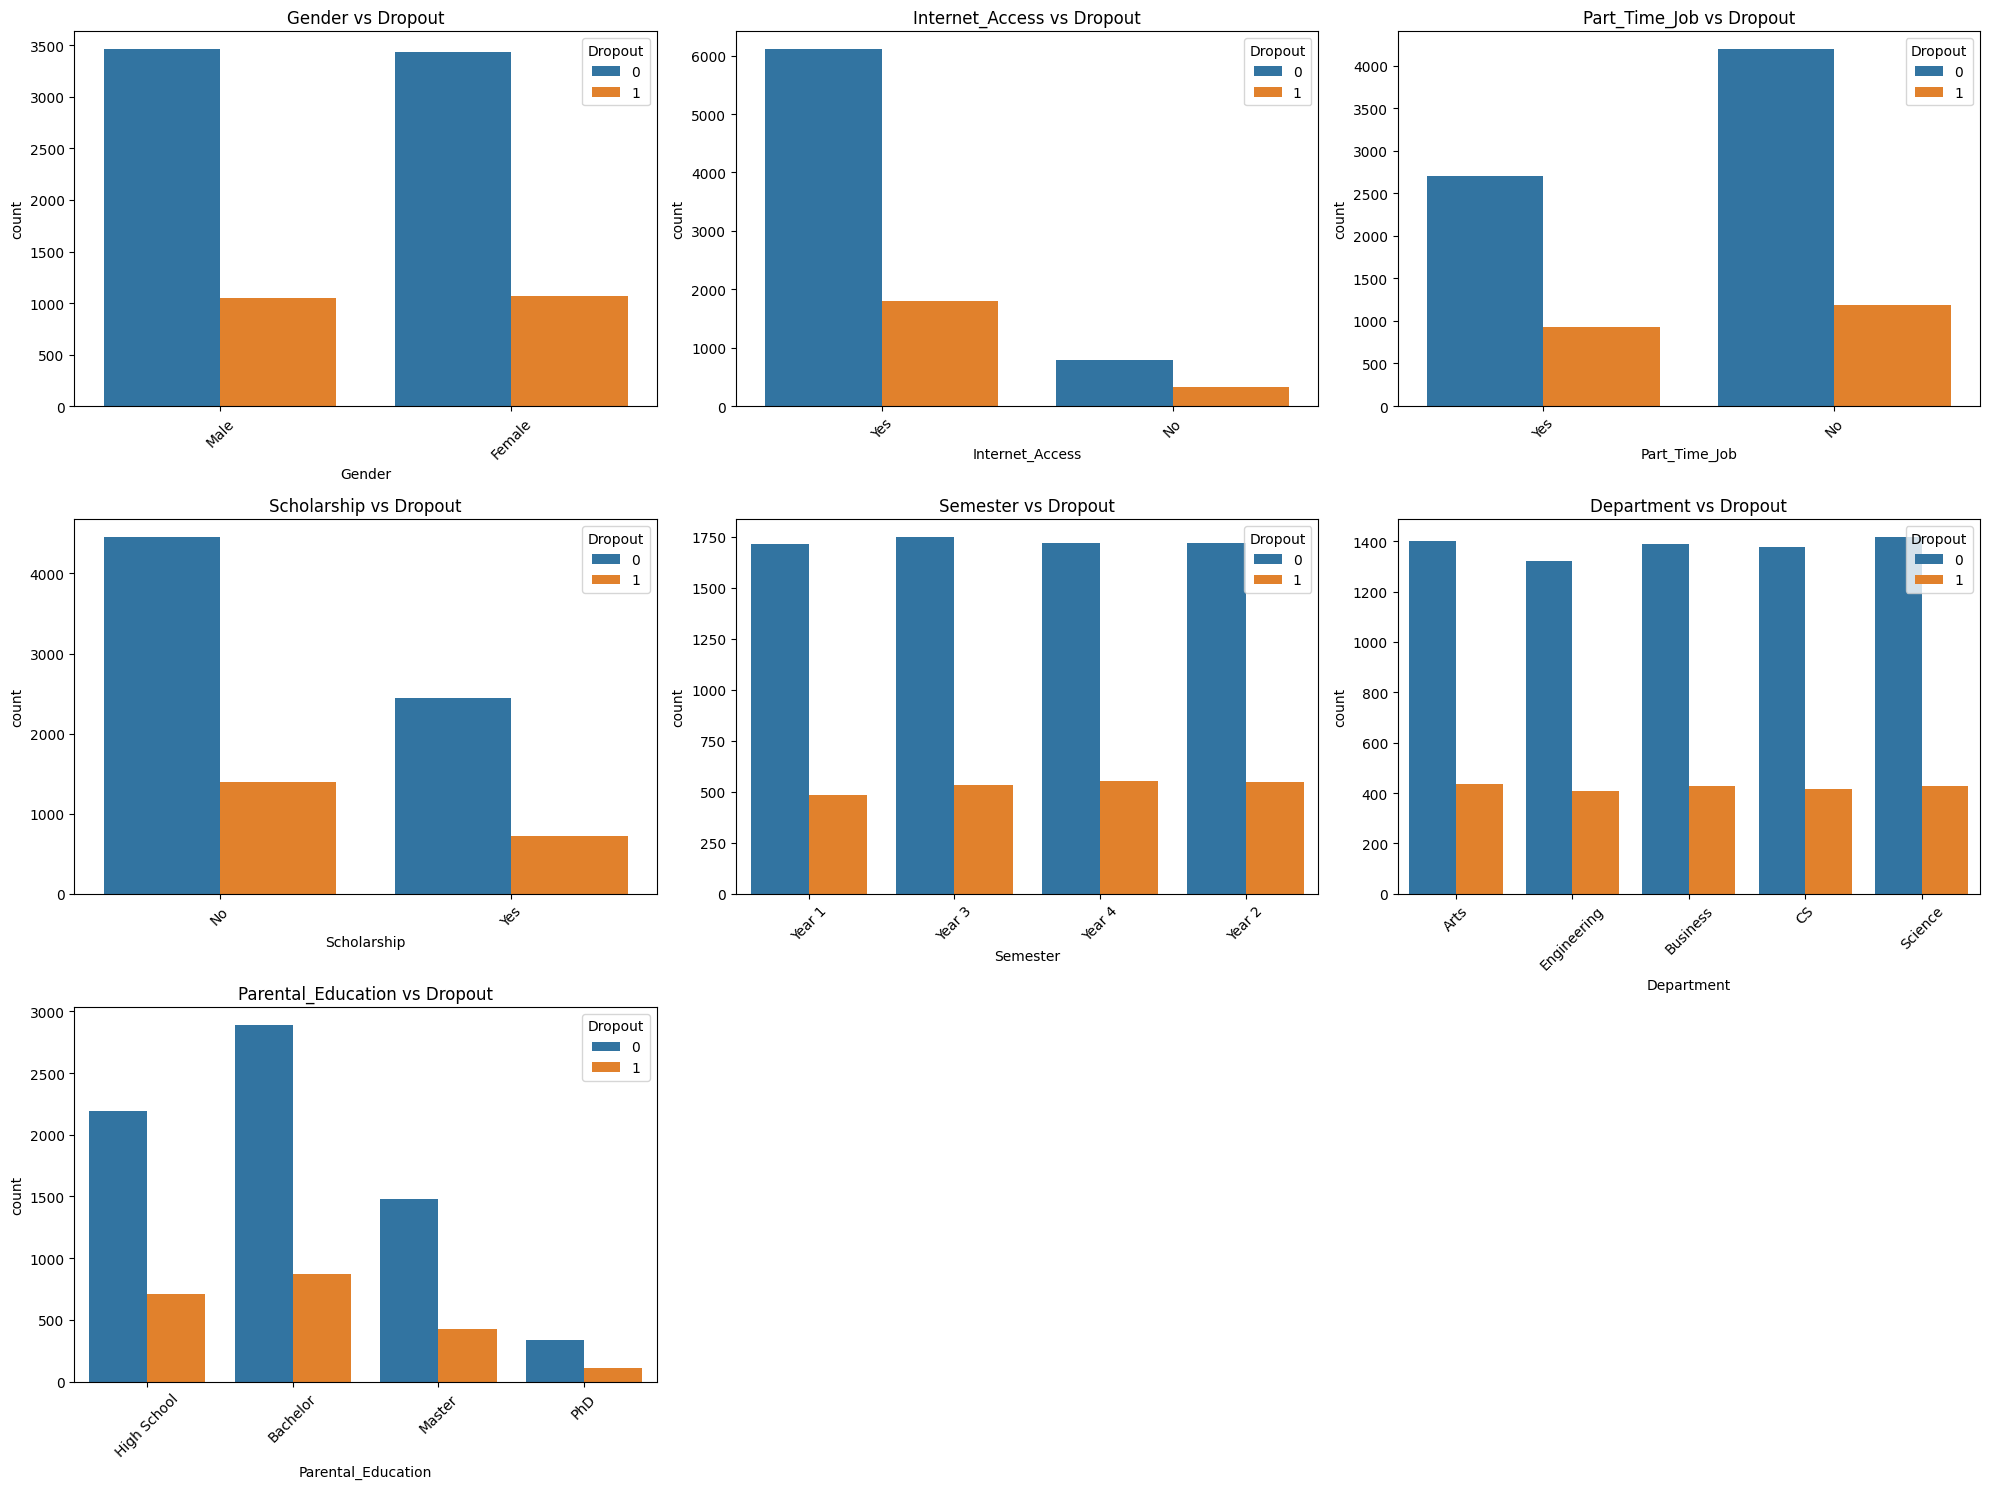

In [369]:
n_cols = 3
n_rows = math.ceil(len(vars_categoricas) / n_cols)

fig, axis = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

axis = np.array(axis).flatten()  

for i, col in enumerate(vars_categoricas):
    sns.countplot(
        ax=axis[i],
        data=total_data,
        x=col,
        hue=target
    )
    axis[i].set_title(f"{col} vs {target}")
    axis[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si sobran
for j in range(len(vars_categoricas), len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

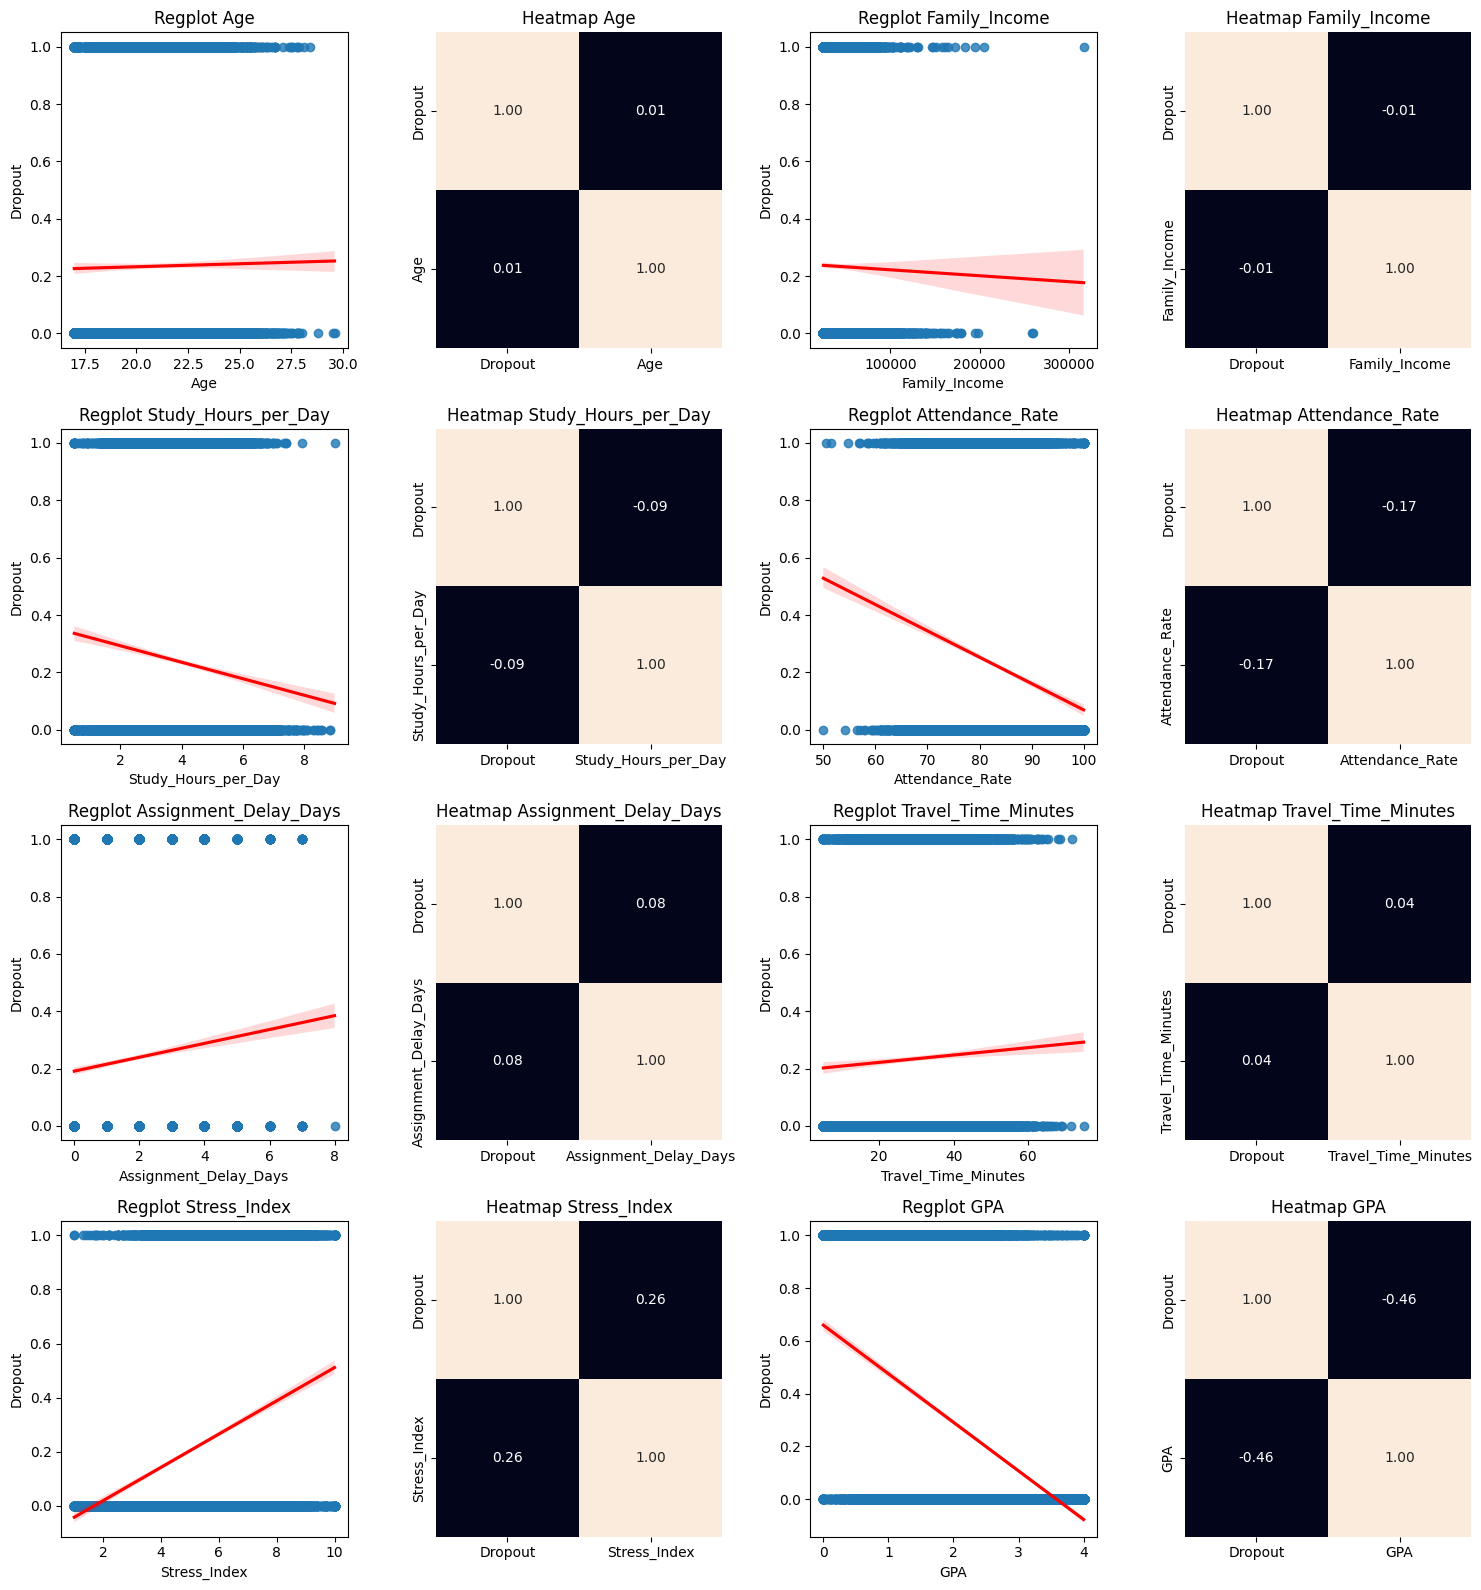

In [370]:
n_cols = 4
target="Dropout"
vars_num_sin_pred=[col for col in vars_numericas if col != target]
n_rows =2*( math.ceil(len(vars_num_sin_pred) / n_cols))

fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axis = axis.flatten()
for i, col in enumerate(vars_num_sin_pred):
    sns.regplot(ax = axis[2*i], data = total_data, x = col, y = target,line_kws={"color": "red"})
    axis[2*i].set_title(f"Regplot {col}")
    sns.heatmap(total_data[[target,col]].corr(), annot = True, fmt = ".2f", ax = axis[2*i + 1], cbar = False)
    axis[2*i + 1].set_title(f"Heatmap {col}")

# Eliminar subplots sobrantes
for j in range(2*i + 2, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

In [371]:
vars_categoricas_n = []

for col in vars_categoricas:
    
    total_data[f"{col}_n"] = pd.factorize(total_data[col])[0]
    
    transformation_rules = dict(
        total_data[[col, f"{col}_n"]]
        .drop_duplicates()
        .values
    )
    
    with open(f"./{col}_transformation_rules.json", "w") as f:
        json.dump(transformation_rules, f)
    
    vars_categoricas_n.append(f"{col}_n")  
variables=vars_numericas+vars_categoricas_n
total_data=total_data[variables]

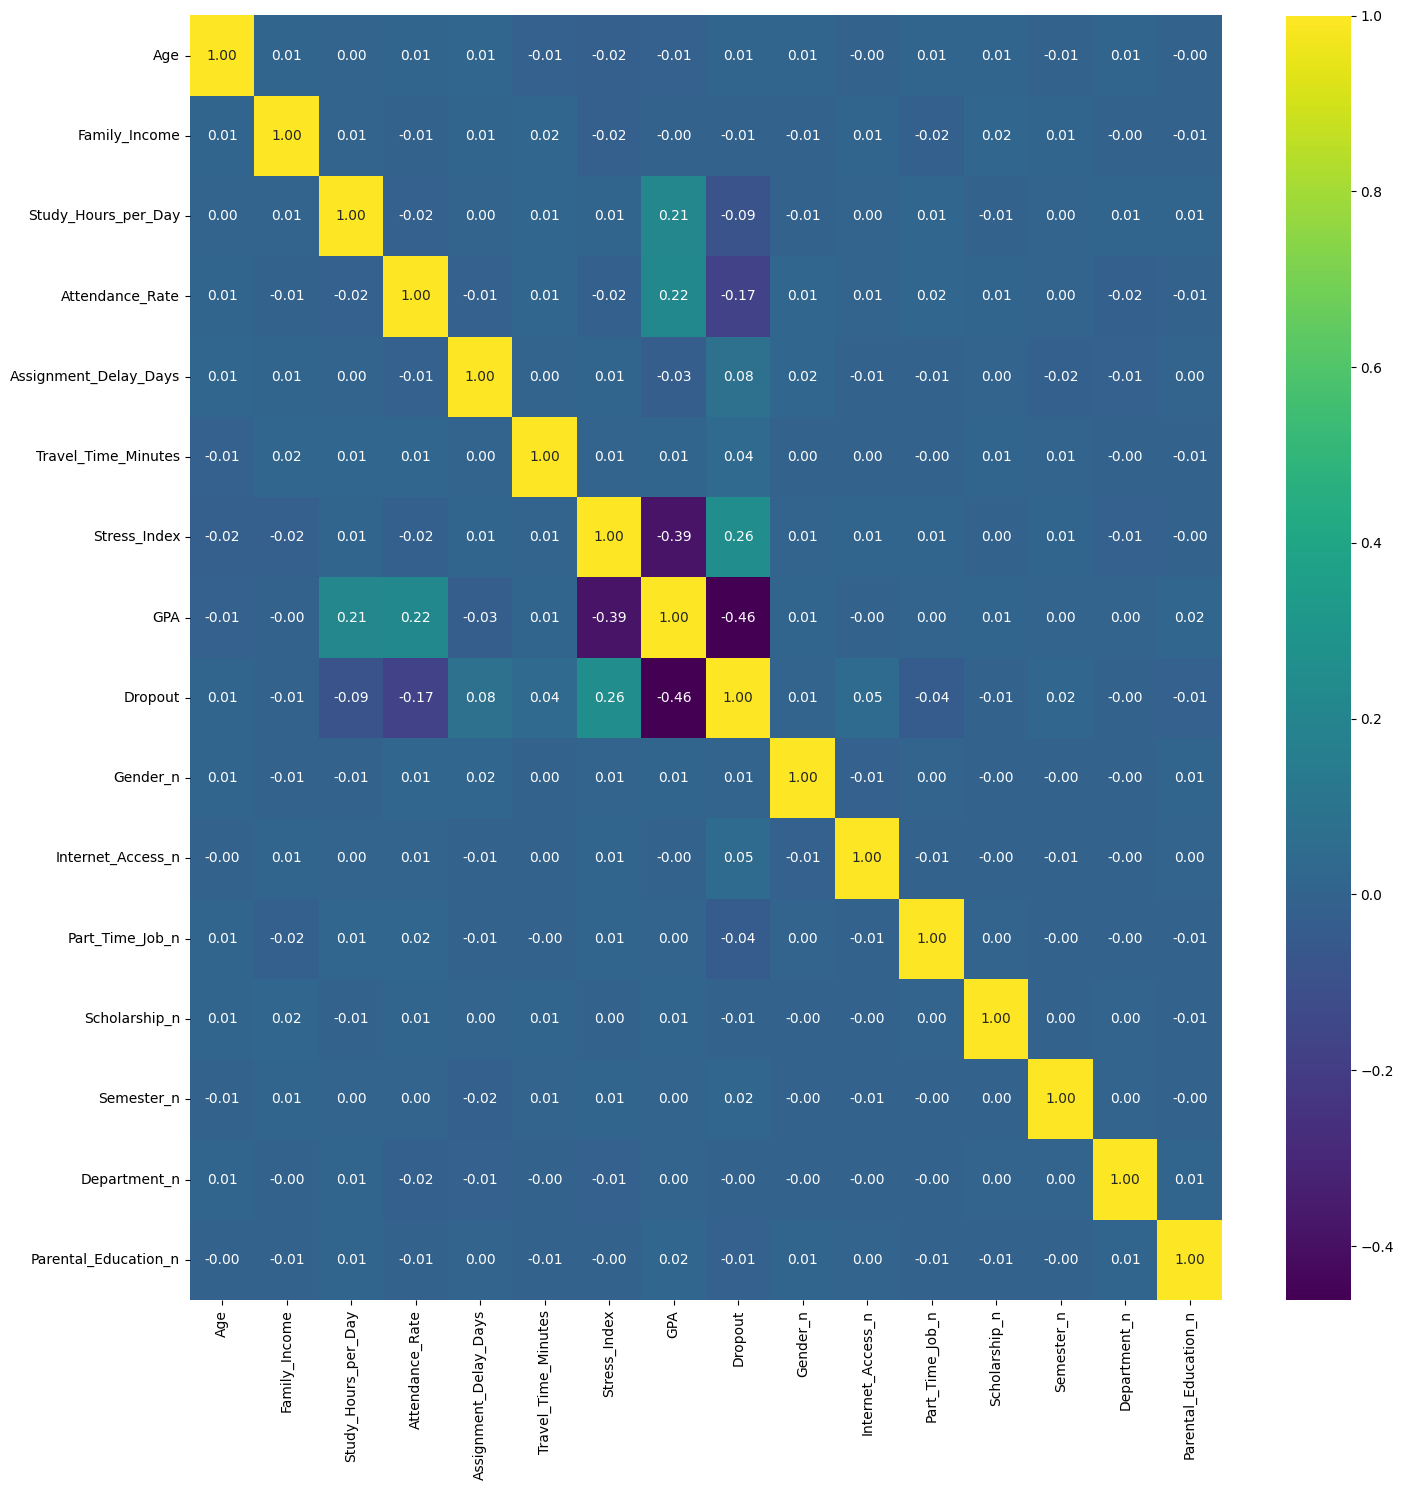

In [372]:
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(total_data.corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

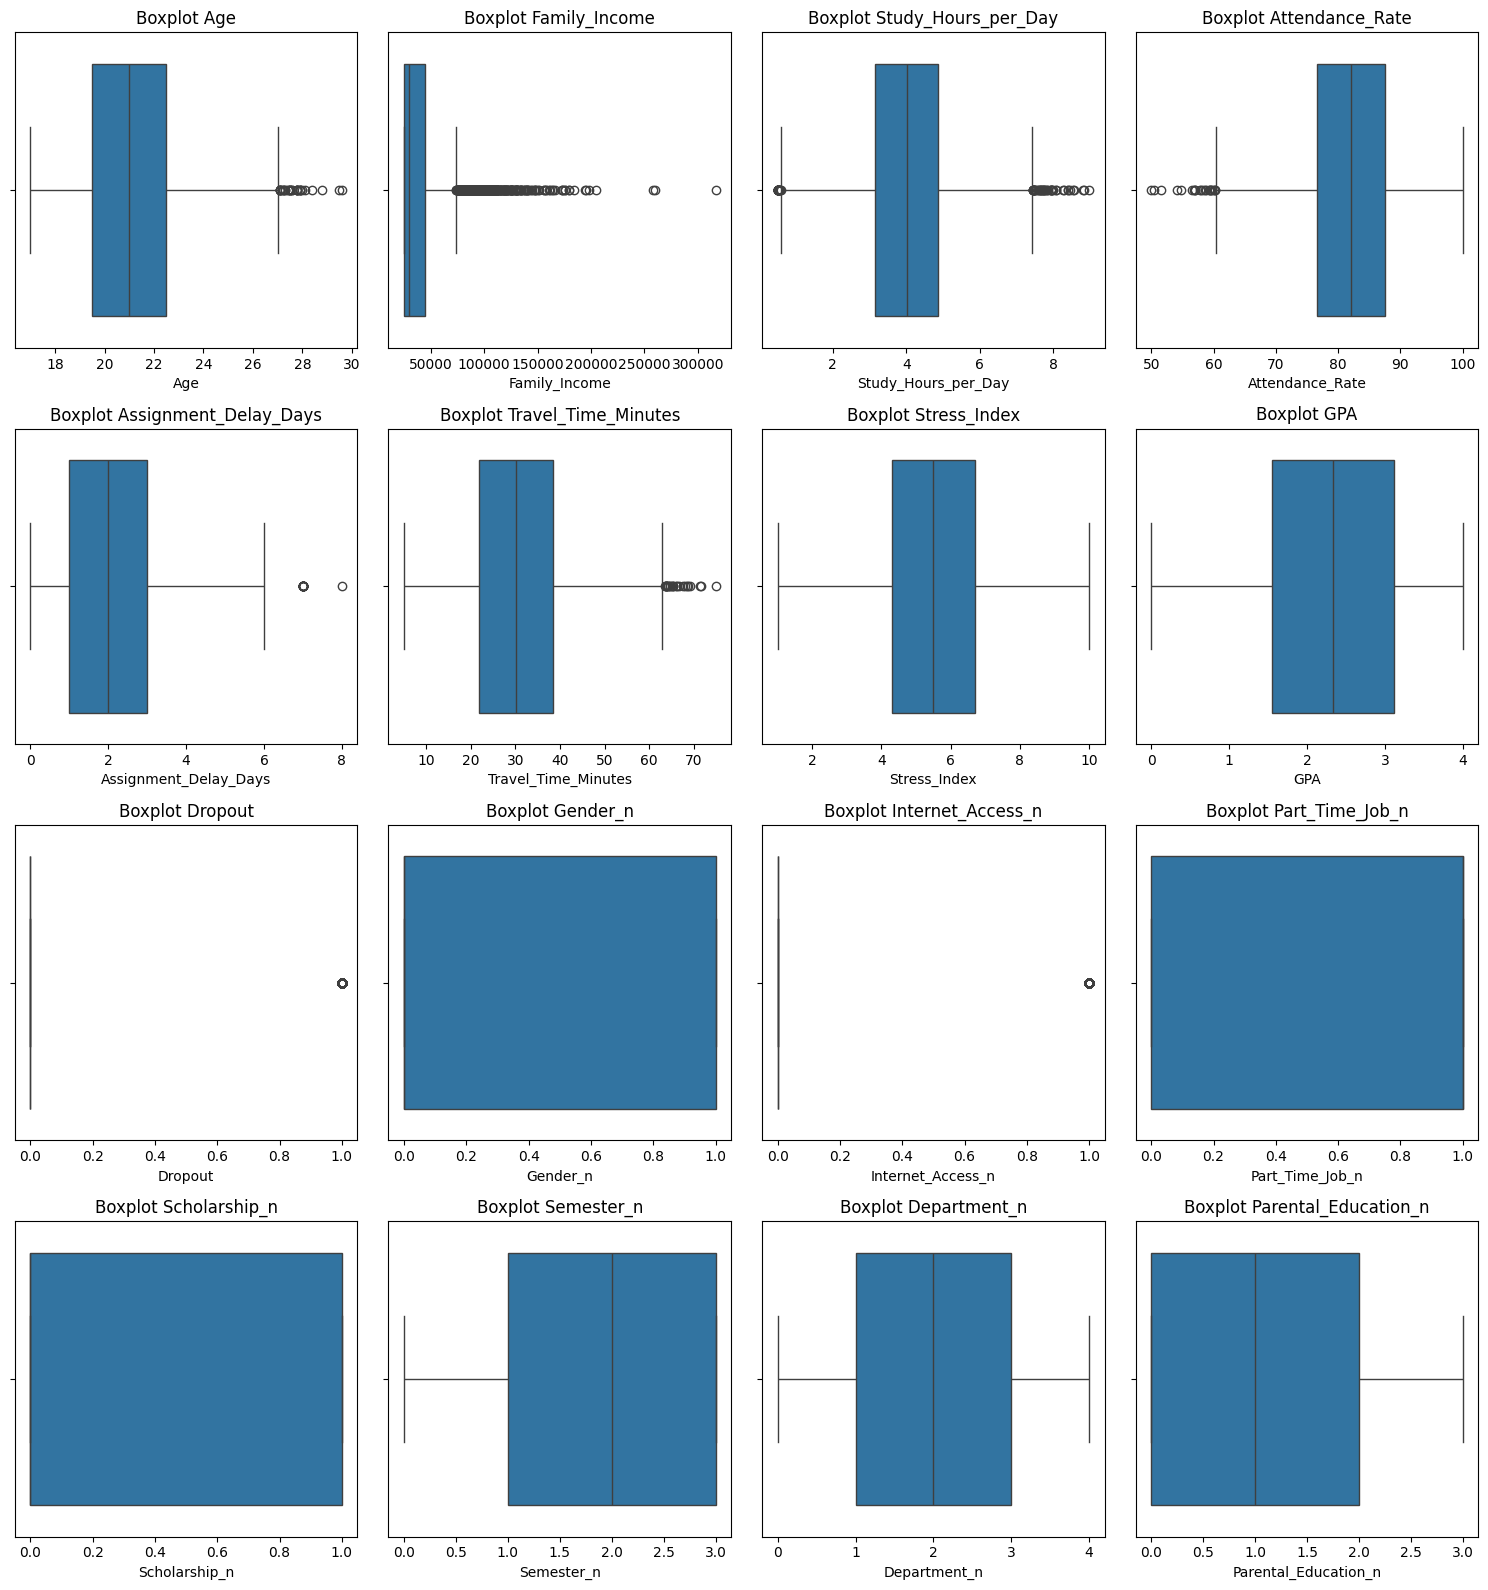

In [373]:
n_cols = 4
n_rows = math.ceil(len(variables) / n_cols)

fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axis = axis.flatten()

for i, col in enumerate(variables):
    sns.boxplot(data=total_data, x=col, ax=axis[i])
    axis[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

In [374]:
predictoras=[col for col in variables if col != target]
total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = predictoras

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [375]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)


Age                      0
Family_Income            0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Dropout                  0
Gender_n                 0
Internet_Access_n        0
Part_Time_Job_n          0
Scholarship_n            0
Semester_n               0
Department_n             0
Parental_Education_n     0
dtype: int64

In [376]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

Age                      0
Family_Income            0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Dropout                  0
Gender_n                 0
Internet_Access_n        0
Part_Time_Job_n          0
Scholarship_n            0
Semester_n               0
Department_n             0
Parental_Education_n     0
dtype: int64

In [377]:
# total_data_SIN_outliers
# total_data_CON_outliers
X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)

In [378]:
# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [379]:
X_train_CON_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/y_train.xlsx", index = False)
y_test.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/y_test.xlsx", index = False)

# SCALERS


with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)

In [380]:
datasets = [
    X_train_CON_outliers,
    X_train_CON_outliers_norm,
    X_train_CON_outliers_scal,
    X_train_SIN_outliers,
    X_train_SIN_outliers_norm,
    X_train_SIN_outliers_scal
]
dataset_names = [
    "X_train_CON_outliers",
    "X_train_CON_outliers_norm",
    "X_train_CON_outliers_scal",
    "X_train_SIN_outliers",
    "X_train_SIN_outliers_norm",
    "X_train_SIN_outliers_scal"]

models = []
accs = []
for i,dataset in enumerate(datasets):
  model = LogisticRegression(random_state=10) # Regresión Logística
  model.fit(dataset, y_train) # Entreno el modelo
  y_pred = model.predict(dataset)
  acc = accuracy_score(y_train, y_pred)
  accs.append(acc)
  models.append(model)
  print(f"Accuracy del dataset {i}: {acc:.4f}")

best_acc = max(accs)
best_index = accs.index(best_acc)
print(f"\nEl mejor dataset es el dataset {best_index}, es decir, {dataset_names[best_index]} con accuracy = {best_acc:.4f}")

Accuracy del dataset 0: 0.8022
Accuracy del dataset 1: 0.8139
Accuracy del dataset 2: 0.8135
Accuracy del dataset 3: 0.8024
Accuracy del dataset 4: 0.8122
Accuracy del dataset 5: 0.8136

El mejor dataset es el dataset 1, es decir, X_train_CON_outliers_norm con accuracy = 0.8139


In [381]:
params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}


grid = GridSearchCV(LogisticRegression(random_state=10), params, scoring = "accuracy")
grid.fit(datasets[best_index], y_train) # Entreno el optimizador con el dataset GANADOR
print(grid.best_params_)
best_model = grid.best_estimator_

{'C': 0.001, 'penalty': None, 'solver': 'newton-cg'}


In [382]:
model_grid = LogisticRegression(penalty = None , C = 0.001, solver = "newton-cg")
model_grid.fit(datasets[best_index], y_train)
y_pred = model_grid.predict(X_test_CON_outliers_norm)

grid_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy anterior: {best_acc}")
print(f"Accuracy optimizado: {grid_accuracy}")

Accuracy anterior: 0.8138858093126385
Accuracy optimizado: 0.8087583148558758


In [383]:
datasets[best_index]

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Gender_n,Internet_Access_n,Part_Time_Job_n,Scholarship_n,Semester_n,Department_n,Parental_Education_n
7210,2.417082,-0.138497,0.429555,1.046524,-0.594296,-1.995948,-0.118481,-0.712793,-0.994472,-0.371230,0.820888,-0.741728,-1.364387,1.404736,1.181978
5813,-0.892045,0.134431,-0.990675,-0.883330,-1.336498,0.094916,0.674724,-2.035238,1.005559,-0.371230,-1.218193,-0.741728,-0.463370,-0.001657,-1.159588
4421,-1.125082,-0.649028,1.283245,2.262082,-0.594296,1.469388,-0.118481,0.046910,1.005559,2.693751,-1.218193,1.348202,1.338665,-1.408049,0.011195
8954,-0.286149,0.140662,0.530446,-1.096365,-0.594296,0.986240,-2.554755,1.585072,1.005559,2.693751,0.820888,1.348202,-0.463370,-1.408049,0.011195
9755,1.065467,1.660846,1.221159,0.181849,1.632309,0.536413,-1.421605,1.585072,-0.994472,-0.371230,-1.218193,-0.741728,-1.364387,1.404736,-1.159588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,1.112074,-0.416602,-2.651490,-1.296870,-1.336498,0.353150,0.108149,-0.928511,-0.994472,2.693751,-1.218193,1.348202,1.338665,0.701540,1.181978
8083,0.785822,4.053596,1.050421,-1.008645,-1.336498,0.161557,0.448094,-0.431422,1.005559,-0.371230,-1.218193,-0.741728,1.338665,-1.408049,-1.159588
1489,1.298504,-0.043687,-0.610394,0.094129,0.147905,0.811307,-0.515084,0.459587,1.005559,-0.371230,-1.218193,-0.741728,1.338665,-0.001657,0.011195
8085,0.226533,0.001897,0.041514,0.896146,-1.336498,2.044167,1.014669,-0.084397,1.005559,-0.371230,0.820888,-0.741728,1.338665,1.404736,0.011195


## **Paso 3: Desarrolla una aplicación web usando Flask**

In [387]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model_grid, f)